In [1]:
import os
import sys
import copy
import gc

os.environ["CUDA_DEVICE_ORDER"]    = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import torch
from matplotlib import pyplot as plt
from scipy.io import savemat
from tqdm.notebook import tqdm

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from models.config import get_config
from models.utils import mosaic, rm_bg
from models.UnrolledNet import UnrolledNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
save_path  = './'
model_name = save_path + 'FINDER.weights.h5'
res_name   = save_path + 'results/FINDER.mat'
data_path   = './data'

nx=220  ny=220  nz=32  nc=32  nd=32


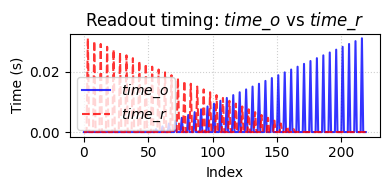

In [3]:
# Configuration
config = get_config(
    nx=220, ny=220, nz=32, nc=32, nd=32,
    esp=9.4e-4,
)
# Load Readout timing
config.time_o = np.load(os.path.join(data_path, 'timing', 'time_o.npy'))
config.time_r = np.load(os.path.join(data_path, 'timing', 'time_r.npy'))
config.fftmtx = np.load(os.path.join(data_path, 'timing', 'fftmtx.npy'))

nx, ny, nz, nc, nd = config.nx, config.ny, config.nz, config.nc, config.nd
print(f"nx={nx}  ny={ny}  nz={nz}  nc={nc}  nd={nd}")

plt.figure(figsize=(4, 2))
plt.plot(config.time_o, label='$time\_o$', color='blue',  alpha=0.8)
plt.plot(config.time_r, label='$time\_r$', color='red', linestyle='--', alpha=0.8)
plt.title('Readout timing: $time\_o$ vs $time\_r$', fontsize=12)
plt.xlabel('Index'); plt.ylabel('Time (s)')
plt.legend(); plt.grid(True, linestyle=':', alpha=0.6); plt.tight_layout()
plt.show()

In [4]:
model = UnrolledNet(config, device=device).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters:     4,955,267
Trainable Parameters: 4,955,027


In [5]:
target_slice = 16
target_diffs = [0, 8, 16, 24]
n_diff       = len(target_diffs)
z            = target_slice

# Load data
csm_np   = np.load(os.path.join(data_path, 'csm',   f'csm_z{z:03d}.npy'))
coord_np = np.load(os.path.join(data_path, 'coord', f'coord_z{z:03d}.npy'))

kdata_np = np.stack([np.load(os.path.join(data_path, 'kdata',       f'kdata_z{z:03d}_q{q:03d}.npy')) for q in target_diffs], axis=0)   # (n_diff, nc, nx, ny, 2)
mask_np  = np.stack([np.load(os.path.join(data_path, 'mask',        f'mask_org_z{z:03d}_q{q:03d}.npy')) for q in target_diffs], axis=0) # (n_diff, nx, ny, 2)
field_np = np.stack([np.load(os.path.join(data_path, 'field_sense', f'field_z{z:03d}_q{q:03d}.npy')) for q in target_diffs], axis=0)    # (n_diff, nx, ny)
sense_np = np.stack([np.load(os.path.join(data_path, 'sense',       f'sense_z{z:03d}_q{q:03d}.npy')) for q in target_diffs], axis=0)    # (n_diff, 2, nx, ny)
bvec_np  = np.stack([np.load(os.path.join(data_path, 'bvec',        f'bvec_q{q:03d}.npy')) for q in target_diffs], axis=0)              # (n_diff, 3)

print(f"Loaded {n_diff} samples  (slice={target_slice}, diffs={target_diffs})")
print(f"kdata: {kdata_np.shape}, mask: {mask_np.shape}, field: {field_np.shape}")
print(f"sense: {sense_np.shape}, bvec: {bvec_np.shape}, csm: {csm_np.shape}")

Loaded 4 samples  (slice=16, diffs=[0, 8, 16, 24])
kdata: (4, 32, 220, 220, 2), mask: (4, 1, 220, 220, 2), field: (4, 220, 220)
sense: (4, 2, 220, 220), bvec: (4, 3), csm: (32, 220, 220)


In [6]:
model.eval()

try:
    model.load_state_dict(torch.load(model_name, weights_only=True))
    print(f"Loaded weights: {model_name}")
except Exception as e:
    print(f"Could not load weights ({e})")

bat_kdata = torch.from_numpy(kdata_np).to(device)                                      # (n_diff, nc, nx, ny, 2)
bat_csm   = torch.from_numpy(csm_np).unsqueeze(0).repeat(n_diff, 1, 1, 1).to(device)  # (n_diff, nc, nx, ny)
bat_mask  = torch.from_numpy(mask_np).to(device)                                       # (n_diff, nx, ny, 2)
bat_field = torch.from_numpy(field_np).to(device)                                      # (n_diff, nx, ny)
bat_sense = torch.from_numpy(sense_np).to(device)                                      # (n_diff, 2, nx, ny)
bat_coord = torch.from_numpy(coord_np).unsqueeze(0).repeat(n_diff, 1, 1).to(device)   # (n_diff, nx*ny, 3)
bat_bvec  = torch.from_numpy(bvec_np).to(device)                                       # (n_diff, 3)

print("Inference starts...")
with torch.no_grad():
    x_recon, _, field_est = model(
        bat_kdata, bat_mask, bat_mask,
        bat_csm, bat_field, bat_sense,
        bat_coord, bat_bvec
    )
    x_recon = rm_bg(x_recon, bat_csm)

x_recon_cpu         = x_recon.cpu().numpy()
all_reconstructions = (x_recon_cpu[:, 0:2, :, :] +
                       1j * x_recon_cpu[:, 2:4, :, :])   # (n_diff, 2, nx, ny)
all_field           = field_est.cpu().numpy()             # (n_diff, nx, ny)

print(f"all_reconstructions: {all_reconstructions.shape}")
print(f"all_field:           {all_field.shape}")

Loaded weights: ./FINDER.weights.h5
Inference starts...
all_reconstructions: (4, 2, 220, 220)
all_field:           (4, 220, 220)


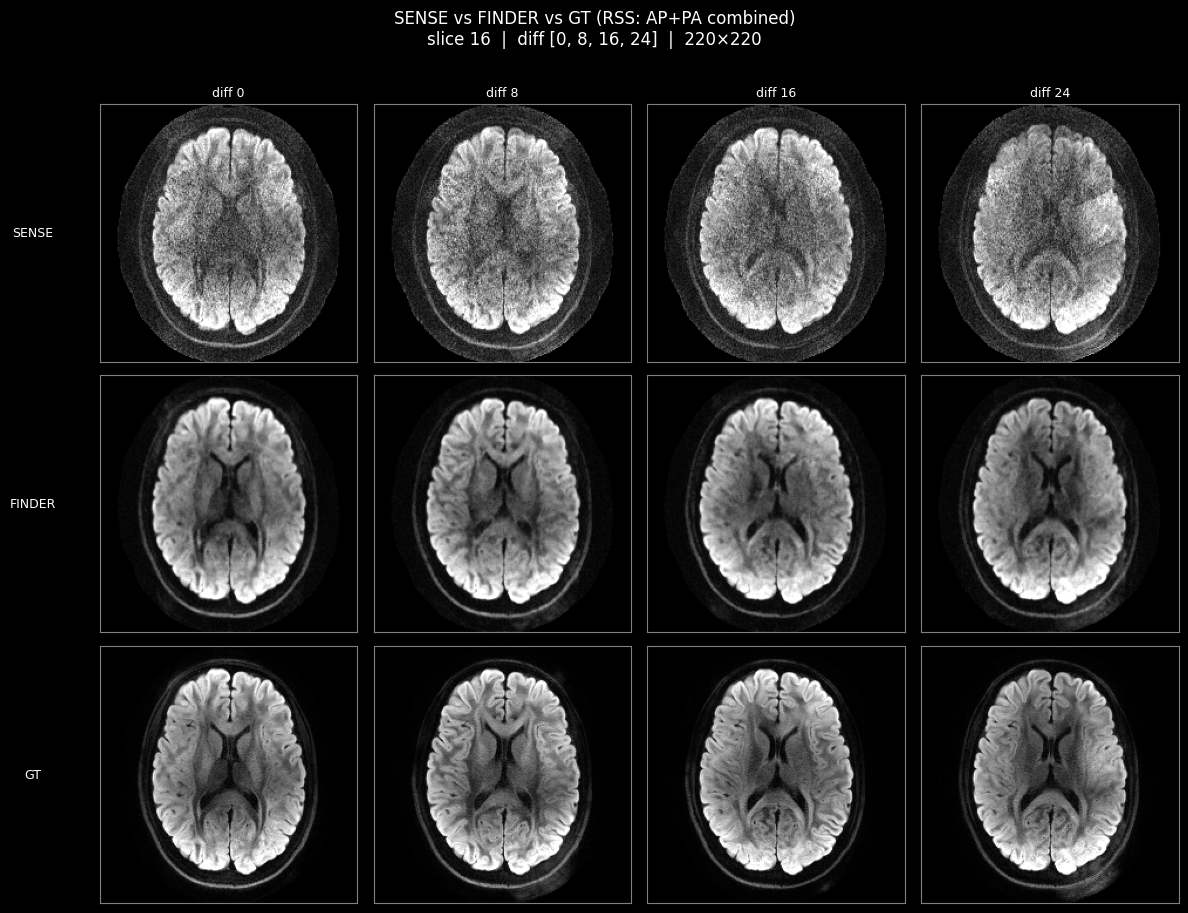

In [7]:
gt_img_base = './data/gt/img/'
gt_ap = [np.abs(np.load(f"{gt_img_base}img_gt_z016_q{d:03d}_000.npy"))
         for d in target_diffs]
gt_pa = [np.abs(np.load(f"{gt_img_base}img_gt_z016_q{d:03d}_001.npy"))
         for d in target_diffs]

ref_ap  = [np.rot90(np.abs(sense_np[i, 0])) for i in range(n_diff)]
ref_pa  = [np.rot90(np.abs(sense_np[i, 1])) for i in range(n_diff)]
rec_ap  = [np.rot90(np.abs(all_reconstructions[i, 0])) for i in range(n_diff)]
rec_pa  = [np.rot90(np.abs(all_reconstructions[i, 1])) for i in range(n_diff)]

ref_rss = [np.sqrt(ap**2 + pa**2) for ap, pa in zip(ref_ap, ref_pa)]
rec_rss = [np.sqrt(ap**2 + pa**2) for ap, pa in zip(rec_ap, rec_pa)]
gt_rss  = [np.sqrt(ap**2 + pa**2) for ap, pa in zip(gt_ap, gt_pa)]

def shared_clim(*img_lists):
    all_vals = np.concatenate([im.ravel() for imgs in img_lists for im in imgs])
    return 0, np.percentile(all_vals, 99)

clim_rss = shared_clim(ref_rss, rec_rss, gt_rss)

row_data = [
    (ref_rss, 'SENSE',  'gray', clim_rss),
    (rec_rss, 'FINDER', 'gray', clim_rss),
    (gt_rss,  'GT',     'gray', clim_rss),
]
n_rows, n_cols = len(row_data), n_diff

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 3, n_rows * 3),
                         facecolor='black')

for r, (imgs, row_label, cmap, clim) in enumerate(row_data):
    vmin, vmax = clim
    for c, (img, diff_idx) in enumerate(zip(imgs, target_diffs)):
        ax = axes[r, c]
        ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
        ax.set_facecolor('black')
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_edgecolor('gray')
        if r == 0:
            ax.set_title(f"diff {diff_idx}", color='white', fontsize=9)
        if c == 0:
            ax.set_ylabel(row_label, color='white', fontsize=9, rotation=0,
                          labelpad=48, va='center')

fig.suptitle(f'SENSE vs FINDER vs GT (RSS: AP+PA combined)\nslice {target_slice}  |  diff {target_diffs}  |  {imgs[0].shape[0]}×{imgs[0].shape[1]}',
             color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

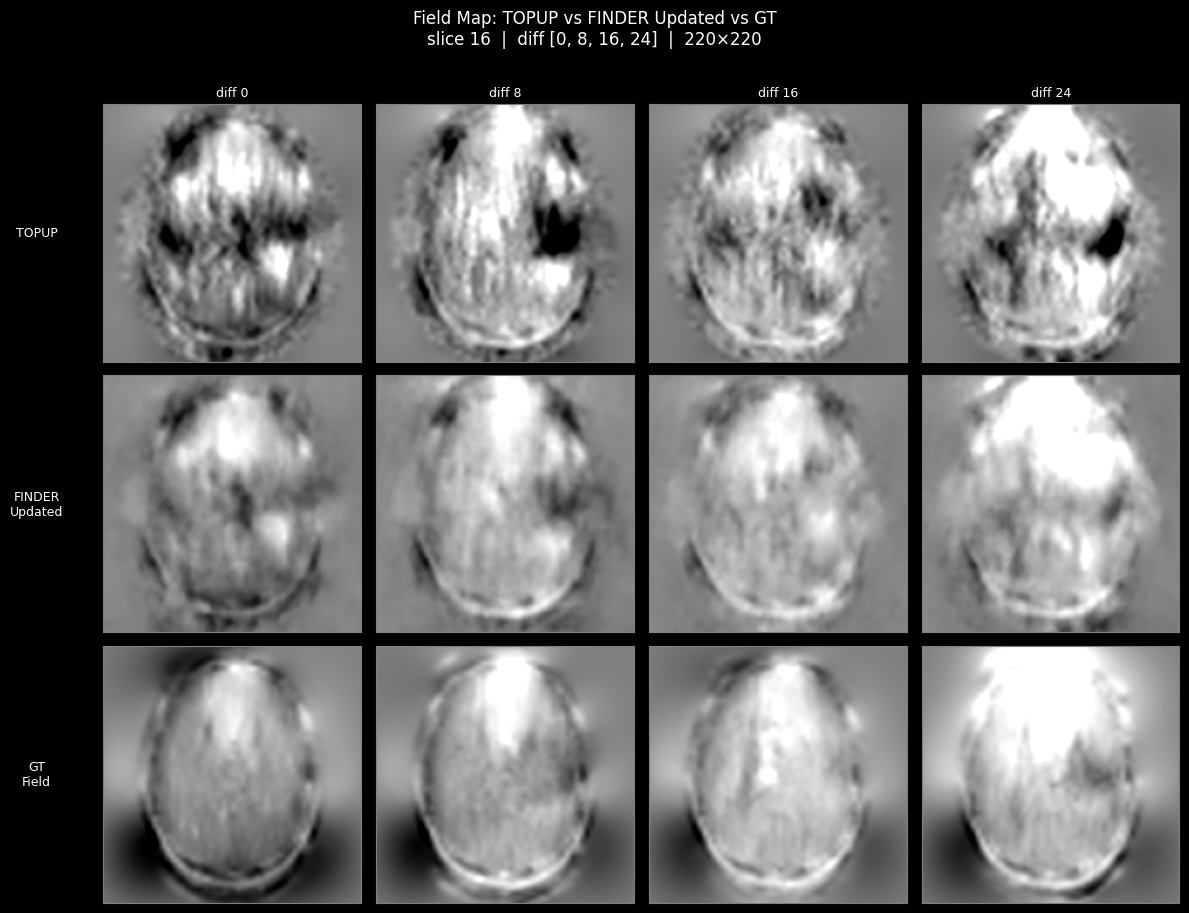

In [8]:
gt_field_base = './data/gt/field/'
fld_gt = [np.load(f"{gt_field_base}field_gt_z016_q{d:03d}.npy")
          for d in target_diffs]

fld_init  = [np.rot90(field_np[i])  for i in range(n_diff)]
fld_recon = [np.rot90(all_field[i]) for i in range(n_diff)]

row_data = [
    (fld_init,  'TOPUP',           'gray', (-50, 50)),
    (fld_recon, 'FINDER\nUpdated', 'gray', (-50, 50)),
    (fld_gt,    'GT\nField',       'gray', (-50, 50)),
]
n_rows, n_cols = len(row_data), n_diff

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 3, n_rows * 3),
                         facecolor='black')

for r, (imgs, row_label, cmap, clim) in enumerate(row_data):
    vmin, vmax = clim
    for c, (img, diff_idx) in enumerate(zip(imgs, target_diffs)):
        ax = axes[r, c]
        ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
        ax.set_facecolor('black')
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_edgecolor('gray')
        if r == 0:
            ax.set_title(f"diff {diff_idx}", color='white', fontsize=9)
        if c == 0:
            ax.set_ylabel(row_label, color='white', fontsize=9, rotation=0,
                          labelpad=48, va='center')

fig.suptitle(f'Field Map: TOPUP vs FINDER Updated vs GT\nslice {target_slice}  |  diff {target_diffs}  |  {imgs[0].shape[0]}×{imgs[0].shape[1]}',
             color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
savemat(res_name, {
    "im_recon": all_reconstructions,
    "im_field": all_field,
})